In [1]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.spatial.distance import pdist
from itertools import combinations


class DistanceTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, x_columns=range(16), y_columns=range(16, 32)):
        self.x_columns = x_columns
        self.y_columns = y_columns
        self.pairs = list(combinations(range(1, 17), 2))
        self.column_names = [f"d_{i}_{j}" for i, j in self.pairs]

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        x = X.iloc[:, self.x_columns].values
        y = X.iloc[:, self.y_columns].values
        coords = np.stack((x, y), axis=2)
        distances = np.array([pdist(sample, metric='euclidean') for sample in coords])
        return pd.concat([
            X.reset_index(drop=True),
            pd.DataFrame(distances, columns=self.column_names, index=X.index).reset_index(drop=True),
        ], axis=1)

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = []
        return np.array(list(input_features) + self.column_names)

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder


def create_nn_pipeline(numeric_cols, location_col='location'):
    numeric_pipeline = Pipeline([
        ("dist", DistanceTransformer(x_columns=numeric_cols[:16], y_columns=numeric_cols[16:32])),
        ("num", StandardScaler())
    ])

    pipeline = Pipeline([
        ("preprocessor", ColumnTransformer(transformers=[
            ('num', numeric_pipeline, numeric_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), [location_col]),
        ], remainder="passthrough"))
    ])
    return pipeline


def create_tree_pipeline(x_cols=range(16), y_cols=range(16, 32), location_col='location'):
    pipeline = Pipeline([
        ('preprocessor', ColumnTransformer(transformers=[
            ("cat", OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), [location_col]),
            ("dist", DistanceTransformer(x_columns=x_cols, y_columns=y_cols), list(x_cols) + list(y_cols))
        ], remainder='passthrough'))
    ])
    return pipeline

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split


def data_loading(path, location):
    df = pd.read_csv(path, header=None)
    rename_cols = lambda col: (
        f'x{c + 1}' if (c := int(col)) < 16 else
        f'y{c % 16 + 1}' if c < 32 else
        f'p{c % 16 + 1}' if c < 48 else
        f'total_power'
    )
    df.rename(columns=rename_cols, inplace=True)
    df['location'] = location

    return df


def data_split(df):
    X = df.drop(df.columns[32:49], axis=1)
    y = df.iloc[:, 32:49]

    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

    return X_train, X_val, X_test, y_train, y_val, y_test


df = pd.concat([
    data_loading('Adelaide_Data.csv', 'Adelaide'),
    data_loading('Perth_Data.csv', 'Perth'),
    data_loading('Sydney_Data.csv', 'Sydney'),
    data_loading('Tasmania_Data.csv', 'Tasmania'),
])

# Raw data (best for Linear Regression, Ridge, Lasso)
X_train, X_val, X_test, y_train, y_val, y_test = data_split(df)

# Create pipelines
nn_pipeline = create_nn_pipeline(numeric_cols=list(range(0, 32)))
tree_pipeline = create_tree_pipeline(x_cols=range(16), y_cols=range(16, 32))

# Data with one-hot encoding, scaling, and pairwise-distances (best for Neural Networks)
nn_X_train = pd.DataFrame(nn_pipeline.fit_transform(X_train), columns=nn_pipeline.get_feature_names_out())
nn_X_val = pd.DataFrame(nn_pipeline.transform(X_val), columns=nn_pipeline.get_feature_names_out())
nn_X_test = pd.DataFrame(nn_pipeline.transform(X_test), columns=nn_pipeline.get_feature_names_out())

# Data with only ordinal encoding (best for Decision Trees, Random Forest, Gradient Boosting models)
tree_X_train = pd.DataFrame(tree_pipeline.fit_transform(X_train), columns=tree_pipeline.get_feature_names_out())
tree_X_val = pd.DataFrame(tree_pipeline.transform(X_val), columns=tree_pipeline.get_feature_names_out())
tree_X_test = pd.DataFrame(tree_pipeline.transform(X_test), columns=tree_pipeline.get_feature_names_out())

print("Raw features shape:", X_train.shape)
print("NN features shape:", nn_X_train.shape)
print("Tree features shape:", tree_X_train.shape)

Raw features shape: (230399, 33)
NN features shape: (230399, 156)
Tree features shape: (230399, 153)


# nn_X_train, nn_X_val, nn_X_test -> Ridge / Lasso / Neural Networks

# tree_X_train, tree_X_val, tree_X_test -> Random Forest

In [ ]:
# Advanced Models – Deep Neural Networks

In [4]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

power_cols = [f"p{i}" for i in range(1, 17)]

y_train_power = y_train[power_cols].to_numpy(dtype=np.float32)
y_val_power = y_val[power_cols].to_numpy(dtype=np.float32)
y_test_power = y_test[power_cols].to_numpy(dtype=np.float32)

X_train_nn = nn_X_train.to_numpy(dtype=np.float32)
X_val_nn = nn_X_val.to_numpy(dtype=np.float32)
X_test_nn = nn_X_test.to_numpy(dtype=np.float32)

y_mean = y_train_power.mean(axis=0)
y_std = y_train_power.std(axis=0) + 0.00000001

y_train_scaled = (y_train_power - y_mean) / y_std
y_val_scaled = (y_val_power - y_mean) / y_std
y_test_scaled = (y_test_power - y_mean) / y_std

batch_size = 2048

train_dataset = TensorDataset(
    torch.tensor(X_train_nn),
    torch.tensor(y_train_scaled)
)

val_dataset = TensorDataset(
    torch.tensor(X_val_nn),
    torch.tensor(y_val_scaled)
)

test_dataset = TensorDataset(
    torch.tensor(X_test_nn),
    torch.tensor(y_test_scaled)
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

input_dim = X_train_nn.shape[1]
output_dim = len(power_cols)

print("Input dimension:", input_dim)
print("Output dimension:", output_dim)

Input dimension: 156
Output dimension: 16


In [5]:
def inverse_scale(y_scaled):
    return y_scaled * y_std + y_mean


def rmse_mae(y_true, y_pred):
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    mae = float(np.mean(np.abs(y_true - y_pred)))
    return rmse, mae


def predict_scaled(model, loader, device="cpu"):
    model.eval()
    true_vals = []
    pred_vals = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            preds = model(X_batch).cpu().numpy()
            true_vals.append(y_batch.numpy())
            pred_vals.append(preds)

    return np.vstack(true_vals), np.vstack(pred_vals)


def get_total_power(y_scaled):
    power_values = inverse_scale(y_scaled)
    return power_values.sum(axis=1)


def train_model(model, train_loader, val_loader, lr=0.001, weight_decay=0.0,
                max_epochs=60, patience=10, device="cpu"):

    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_weights = None
    best_epoch = 0
    epochs_no_improve = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_total = 0.0
        train_count = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            preds = model(X_batch)
            loss = loss_fn(preds, y_batch)
            loss.backward()
            optimizer.step()

            train_total += loss.item() * X_batch.size(0)
            train_count += X_batch.size(0)

        train_loss = train_total / train_count

        model.eval()
        val_total = 0.0
        val_count = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                preds = model(X_batch)
                loss = loss_fn(preds, y_batch)

                val_total += loss.item() * X_batch.size(0)
                val_count += X_batch.size(0)

        val_loss = val_total / val_count

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_weights = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

        print(f"Epoch {epoch:02d} , train={train_loss:.5f} , val={val_loss:.5f}")

    if best_weights is not None:
        model.load_state_dict(best_weights)

    return model, history, best_epoch

In [8]:
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden=(128, 64), dropout=0.0, batchnorm=False):
        super().__init__()

        layers = []
        prev_dim = input_dim

        for h in hidden:
            layers.append(nn.Linear(prev_dim, h))

            if batchnorm:
                layers.append(nn.BatchNorm1d(h))

            layers.append(nn.ReLU())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            prev_dim = h

        layers.append(nn.Linear(prev_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


baseline_model = MLP(input_dim, output_dim, hidden=(128, 64), dropout=0.0, batchnorm=False)
regularized_model = MLP(input_dim, output_dim, hidden=(256, 128, 64), dropout=0.2, batchnorm=True)
tuned_model = MLP(input_dim, output_dim, hidden=(512, 256, 128, 64), dropout=0.25, batchnorm=True)

models = {
    "MLP_Baseline": (
       baseline_model,
       {"lr": 0.001, "weight_decay": 0.0, "max_epochs": 40, "patience": 7}
    ),
    "MLP_Regularized": (
       regularized_model,
       {"lr": 0.0008, "weight_decay": 0.0001, "max_epochs": 60, "patience": 10}
    ),
    "MLP_Tuned": (
        tuned_model,
        {"lr": 0.0005, "weight_decay": 0.0003, "max_epochs": 40, "patience": 12}
    ),
}

results = []
histories = {}

for model_name, (model, settings) in models.items():
    print("Training:", model_name)

    trained_model, history, best_epoch = train_model(
        model,
        train_loader,
        val_loader,
        **settings
    )

    histories[model_name] = history

    y_true_scaled, y_pred_scaled = predict_scaled(trained_model, test_loader)
    y_true_total = get_total_power(y_true_scaled)
    y_pred_total = get_total_power(y_pred_scaled)

    rmse, mae = rmse_mae(y_true_total, y_pred_total)

    results.append({
        "Model": model_name,
        "BestEpoch": best_epoch,
        "RMSE": rmse,
        "MAE": mae
    })

    print(f"{model_name} | BestEpoch={best_epoch} | Total RMSE={rmse:,.2f} | Total MAE={mae:,.2f}")

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df

Training: MLP_Tuned
Epoch 01 , train=0.42034 , val=0.06695
Epoch 02 , train=0.11285 , val=0.05888
Epoch 03 , train=0.08903 , val=0.05660
Epoch 04 , train=0.07967 , val=0.05477
Epoch 05 , train=0.07455 , val=0.05394
Epoch 06 , train=0.07121 , val=0.05159
Epoch 07 , train=0.06894 , val=0.05048
Epoch 08 , train=0.06743 , val=0.04889
Epoch 09 , train=0.06635 , val=0.04717
Epoch 10 , train=0.06510 , val=0.04644
Epoch 11 , train=0.06435 , val=0.04530
Epoch 12 , train=0.06351 , val=0.04487
Epoch 13 , train=0.06286 , val=0.04304
Epoch 14 , train=0.06231 , val=0.04251
Epoch 15 , train=0.06150 , val=0.04188
Epoch 16 , train=0.06139 , val=0.04155
Epoch 17 , train=0.06087 , val=0.04136
Epoch 18 , train=0.06062 , val=0.04094
Epoch 19 , train=0.06041 , val=0.04080
Epoch 20 , train=0.06057 , val=0.04051
Epoch 21 , train=0.05986 , val=0.03958
Epoch 22 , train=0.06027 , val=0.04017
Epoch 23 , train=0.06137 , val=0.04144
Epoch 24 , train=0.05990 , val=0.03961
Epoch 25 , train=0.05971 , val=0.03953
Epoch

,Model,BestEpoch,RMSE,MAE
0,MLP_Tuned,40,44047.539062,34113.773438


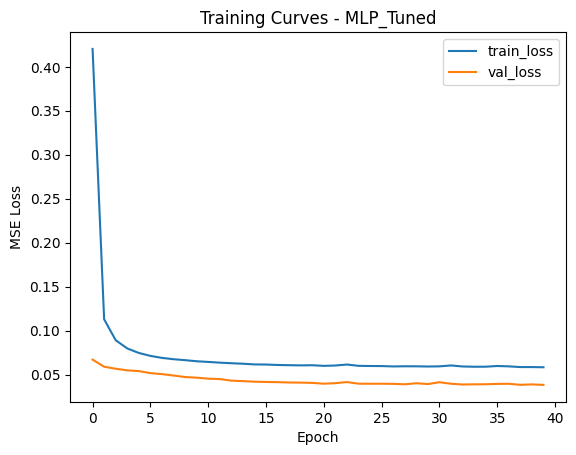

In [9]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.figure()
    plt.plot(history["train_loss"], label="train_loss")
    plt.plot(history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(title)
    plt.legend()
    plt.show()

for name, hist in histories.items():
    plot_history(hist, f"Training Curves - {name}")

In [10]:
def get_activation(name):
    name = name.lower()

    if name == "relu":
        return nn.ReLU()
    elif name == "leakyrelu":
        return nn.LeakyReLU(negative_slope=0.01)
    elif name == "gelu":
        return nn.GELU()


class MLPAct(nn.Module):
    def __init__(self, input_dim, output_dim, hidden=(256, 128, 64), dropout=0.2,
                 batchnorm=True, activation="relu"):
        super().__init__()

        layers = []
        prev_dim = input_dim
        activation_layer = get_activation(activation)

        for h in hidden:
            layers.append(nn.Linear(prev_dim, h))

            if batchnorm:
                layers.append(nn.BatchNorm1d(h))

            layers.append(activation_layer.__class__())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            prev_dim = h

        layers.append(nn.Linear(prev_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [ ]:
activations = ["relu", "leakyrelu", "gelu"]

activation_results = []

for act in activations:
    print("Testing activation:", act)

    model = MLPAct(
        input_dim=input_dim,
        output_dim=output_dim,
        hidden=(256, 128, 64),
        dropout=0.2,
        batchnorm=True,
        activation=act
    )

    settings = {
        "lr": 0.0008,
        "weight_decay": 0.0001,
        "max_epochs": 60,
        "patience": 10
    }

    trained_model, history, best_epoch = train_model(
        model, train_loader, val_loader, **settings
    )

    y_true_s, y_pred_s = predict_scaled(trained_model, test_loader)
    y_true_total = get_total_power(y_true_s)
    y_pred_total = get_total_power(y_pred_s)

    rmse, mae = rmse_mae(y_true_total, y_pred_total)

    activation_results.append({
        "Activation": act,
        "BestEpoch": best_epoch,
        "RMSE": rmse,
        "MAE": mae
    })

act_df = pd.DataFrame(activation_results).sort_values("RMSE")
act_df

Testing activation: relu
Epoch 01 , train=0.38384 , val=0.06534
Epoch 02 , train=0.09395 , val=0.05653
Epoch 03 , train=0.07571 , val=0.05174
Epoch 04 , train=0.06837 , val=0.04840
Epoch 05 , train=0.06439 , val=0.04556
Epoch 06 , train=0.06168 , val=0.04376
Epoch 07 , train=0.05975 , val=0.04140
Epoch 08 , train=0.05811 , val=0.03961
Epoch 09 , train=0.05695 , val=0.04061
Epoch 10 , train=0.05594 , val=0.03683
Epoch 11 , train=0.05513 , val=0.03711
Epoch 12 , train=0.05439 , val=0.03516
Epoch 13 , train=0.05345 , val=0.03413
Epoch 14 , train=0.05293 , val=0.03332
Epoch 15 , train=0.05248 , val=0.03291
Epoch 16 , train=0.05217 , val=0.03275
Epoch 17 , train=0.05171 , val=0.03144
Epoch 18 , train=0.05090 , val=0.03082
Epoch 19 , train=0.05053 , val=0.03087
Epoch 20 , train=0.05010 , val=0.03007
Epoch 21 , train=0.04995 , val=0.02963
Epoch 22 , train=0.04932 , val=0.03004
Epoch 23 , train=0.04922 , val=0.02981
Epoch 24 , train=0.04901 , val=0.02910
Epoch 25 , train=0.04867 , val=0.03027


In [12]:
best_dnn = results_df.iloc[0]

final_compare = pd.DataFrame([
    {"Model": "Random Forest", "RMSE": np.nan, "MAE": np.nan},
    {"Model": "XGBoost", "RMSE": np.nan, "MAE": np.nan},
    {"Model": "SVR", "RMSE": np.nan, "MAE": np.nan},
    {
        "Model": f'Best DNN ({best_dnn["Model"]}, summed from p1-p16)',
        "RMSE": best_dnn["RMSE"],
        "MAE": best_dnn["MAE"]
    }
])

final_compare

,Model,RMSE,MAE
0,Random Forest,NaN,NaN
1,XGBoost,NaN,NaN
2,SVR,NaN,NaN
3,"Best DNN (MLP_Tuned, summed from p1-p16)",44047.539062,34113.773438


In [ ]:
import numpy as np
from sklearn.model_selection import KFold
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim


X_data_full = np.concatenate([X_train_nn, X_val_nn, X_test_nn], axis=0)
y_data_full = np.concatenate([y_train_scaled, y_val_scaled, y_test_scaled], axis=0)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_results_rmse = []
fold_results_mae = []

tuned_model_settings = {
    "lr": 0.0005,
    "weight_decay": 0.0003,
    "max_epochs": 40,
    "patience": 12
}
hidden_layers = (512, 256, 128, 64)
dropout_rate = 0.25
batch_normalization = True



for fold, (train_idx, val_idx) in enumerate(kf.split(X_data_full)):
    print(f"\n--- Fold {fold+1} ---")
    X_train_fold_tensor = torch.tensor(X_data_full[train_idx], dtype=torch.float32)
    y_train_fold_tensor = torch.tensor(y_data_full[train_idx], dtype=torch.float32)
    X_val_fold_tensor = torch.tensor(X_data_full[val_idx], dtype=torch.float32)
    y_val_fold_tensor = torch.tensor(y_data_full[val_idx], dtype=torch.float32)

    train_dataset_fold = TensorDataset(X_train_fold_tensor, y_train_fold_tensor)
    val_dataset_fold = TensorDataset(X_val_fold_tensor, y_val_fold_tensor)

    batch_size = 2048
    train_loader_fold = DataLoader(train_dataset_fold, batch_size=batch_size, shuffle=True)
    val_loader_fold = DataLoader(val_dataset_fold, batch_size=batch_size, shuffle=False)


    model_fold = MLP(input_dim, output_dim, hidden=hidden_layers,
                     dropout=dropout_rate, batchnorm=batch_normalization)

    trained_model_fold, history_fold, best_epoch_fold = train_model(
        model_fold,
        train_loader_fold,
        val_loader_fold,
        **tuned_model_settings
    )


    y_true_scaled_fold, y_pred_scaled_fold = predict_scaled(trained_model_fold, val_loader_fold)


    y_true_total_fold = get_total_power(y_true_scaled_fold)
    y_pred_total_fold = get_total_power(y_pred_scaled_fold)

    rmse_fold, mae_fold = rmse_mae(y_true_total_fold, y_pred_total_fold)
    fold_results_rmse.append(rmse_fold)
    fold_results_mae.append(mae_fold)

    print(f"Fold {fold+1} | BestEpoch={best_epoch_fold} | RMSE={rmse_fold:.4f} | MAE={mae_fold:.4f}")

print(f"\nAverage Cross-Validation RMSE: {np.mean(fold_results_rmse):.4f}")
print(f"Average Cross-Validation MAE: {np.mean(fold_results_mae):.4f}")

Starting 5-Fold Cross-Validation for Advanced Model...


--- Fold 1 ---
Epoch 01 , train=0.42161 , val=0.06538
Epoch 02 , train=0.11223 , val=0.05812
Epoch 03 , train=0.08926 , val=0.05560
Epoch 04 , train=0.07867 , val=0.05303
Epoch 05 , train=0.07320 , val=0.05123
Epoch 06 , train=0.06974 , val=0.04948
Epoch 07 , train=0.06756 , val=0.04806
Epoch 08 , train=0.06587 , val=0.04697
Epoch 09 , train=0.06455 , val=0.04558
Epoch 10 , train=0.06344 , val=0.04389
Epoch 11 , train=0.06276 , val=0.04234
Epoch 12 , train=0.06174 , val=0.04226
Epoch 13 , train=0.06091 , val=0.04190
Epoch 14 , train=0.06045 , val=0.04103
Epoch 15 , train=0.05998 , val=0.03965
Epoch 16 , train=0.05966 , val=0.03973
Epoch 17 , train=0.05947 , val=0.04098
Epoch 18 , train=0.05909 , val=0.03927
Epoch 19 , train=0.05891 , val=0.03886
Epoch 20 , train=0.05849 , val=0.03804
Epoch 21 , train=0.05902 , val=0.03775
Epoch 22 , train=0.05918 , val=0.03773
Epoch 23 , train=0.05810 , val=0.03828
Epoch 24 , train=0.05794 , val=